**GOAL**: Find a clustering resolution that results in good distribution of samples

Use Sol's genes and databases that include embryonal AND adult expression

In [1]:
from __future__ import annotations
import pandas as pd
import numpy as np
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import warnings
warnings.filterwarnings("ignore")
import hdf5plugin #in case needed for h5ad reading (if previously saved with compression)
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt



input_path1 = "/home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_filt.h5ad"



print("Reading " + input_path1 + "...")
etmr1 = ad.io.read_h5ad(input_path1)
print(etmr1)

pat_info = pd.DataFrame({
    "orig.ident": [
        "GSM8058157_KK22-H-225", "GSM8058158_KK22-H-226", "GSM8058159_KK22-H-227",
        "GSM8058160_KK23-H-507", "GSM8058161_KK23-H-508", "GSM8058162_KK23-H-509",
        "GSM8058163_KK23-H-510", "GSM8058164_KK23-H-511", "GSM8058165_KK23-H-512"
    ],
    "Sample_ID": [
        "KK22-H-225", "KK22-H-226", "KK22-H-227",
        "KK23-H-507", "KK23-H-508", "KK23-H-509",
        "KK23-H-510", "KK23-H-511", "KK23-H-512"
    ],
    "Tumor_Type": [
        "C19MC", "C19MC", "Dicer",
        "C19MC", "C19MC", "C19MC",
        "C19MC", "C19MC", "C19MC"
    ]
})

pat_info_indexed = pat_info.set_index("orig.ident")
etmr1.obs = etmr1.obs.join(pat_info_indexed, on="orig.ident", how="left")





Reading /home/sofia/Projects/etmr/defaria/snRNA/data/processed/snrna_data_filt.h5ad...
AnnData object with n_obs × n_vars = 49124 × 18082
    obs: 'orig.ident', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'log1p'
    layers: 'counts', 'scale.data'


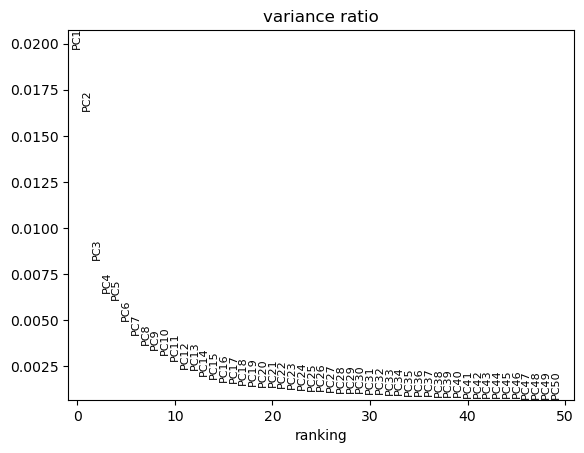

In [2]:

sc.pp.pca(etmr1, use_highly_variable=True, layer="scale.data")
sc.pl.pca_variance_ratio(etmr1, n_pcs=50, log=False)

In [3]:
k_vals  = range(10, 45, 5)      # 10, 15, ..., 40
r_vals  = [0.5, 1.0, 1.5]
pc_vals = range(30, 60, 10)    # 30, 40, 50

for k in k_vals:
    for r in r_vals:
        for pc in pc_vals:

            neigh_key = f"n{k}_pc{pc}"
            umap_key  = f"umap_n{k}_pc{pc}"
            leiden_key = f"leiden_r{r}_n{k}_pc{pc}"

            # Neighbors
            sc.pp.neighbors(
                etmr1,
                n_neighbors=k,
                n_pcs=pc,
                key_added=neigh_key
            )

            # UMAP
            sc.tl.umap(
                etmr1,
                neighbors_key=neigh_key,
                key_added=umap_key
            )

            # Leiden
            sc.tl.leiden(
                etmr1,
                neighbors_key=neigh_key,
                resolution=r,
                key_added=leiden_key
            )

            print(f"Done: k={k}, pc={pc}, res={r}")


Done: k=10, pc=30, res=0.5
Done: k=10, pc=40, res=0.5
Done: k=10, pc=50, res=0.5
Done: k=10, pc=30, res=1.0
Done: k=10, pc=40, res=1.0
Done: k=10, pc=50, res=1.0
Done: k=10, pc=30, res=1.5
Done: k=10, pc=40, res=1.5
Done: k=10, pc=50, res=1.5
Done: k=15, pc=30, res=0.5
Done: k=15, pc=40, res=0.5
Done: k=15, pc=50, res=0.5
Done: k=15, pc=30, res=1.0
Done: k=15, pc=40, res=1.0
Done: k=15, pc=50, res=1.0
Done: k=15, pc=30, res=1.5
Done: k=15, pc=40, res=1.5
Done: k=15, pc=50, res=1.5
Done: k=20, pc=30, res=0.5
Done: k=20, pc=40, res=0.5
Done: k=20, pc=50, res=0.5
Done: k=20, pc=30, res=1.0
Done: k=20, pc=40, res=1.0
Done: k=20, pc=50, res=1.0
Done: k=20, pc=30, res=1.5
Done: k=20, pc=40, res=1.5
Done: k=20, pc=50, res=1.5
Done: k=25, pc=30, res=0.5
Done: k=25, pc=40, res=0.5
Done: k=25, pc=50, res=0.5
Done: k=25, pc=30, res=1.0
Done: k=25, pc=40, res=1.0
Done: k=25, pc=50, res=1.0
Done: k=25, pc=30, res=1.5
Done: k=25, pc=40, res=1.5
Done: k=25, pc=50, res=1.5
Done: k=30, pc=30, res=0.5
D

In [4]:
etmr1

AnnData object with n_obs × n_vars = 49124 × 18082
    obs: 'orig.ident', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sample_ID', 'Tumor_Type', 'leiden_r0.5_n10_pc30', 'leiden_r0.5_n10_pc40', 'leiden_r0.5_n10_pc50', 'leiden_r1.0_n10_pc30', 'leiden_r1.0_n10_pc40', 'leiden_r1.0_n10_pc50', 'leiden_r1.5_n10_pc30', 'leiden_r1.5_n10_pc40', 'leiden_r1.5_n10_pc50', 'leiden_r0.5_n15_pc30', 'leiden_r0.5_n15_pc40', 'leiden_r0.5_n15_pc50', 'leiden_r1.0_n15_pc30', 'leiden_r1.0_n15_pc40', 'leiden_r1.0_n15_pc50', 'leiden_r1.5_n15_pc30', 'leiden_r1.5_n15_pc40', 'leiden_r1.5_n15_pc50', 'leiden_r0.5_n20_pc30', 'leiden_r0.5_n20_pc40', 'leiden_r0.5_n20_pc50', 'leiden_r1.0_n20_pc30', 'leiden_r1.0_n20_pc40', 'leiden_r1.0_n20_pc50', 'leiden_r1.5_n20_pc30', 'leiden_r1.5_n20_pc40', 'leiden_r1.5_n20_pc50', 'leiden_r0.5_n25_pc30', 'leiden_r0.5_n25_pc40', 'leiden_r0.5_n25_pc50', 'leiden_r1.0_n25_pc30', 'leiden_r1.0_n25_pc40', 'leiden_r1.0_n25_pc50', 'leiden_r1.5_n25_pc30', 'leiden_r1

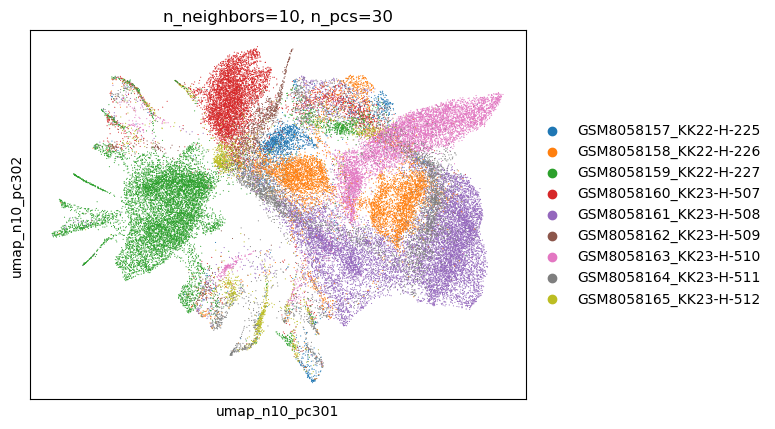

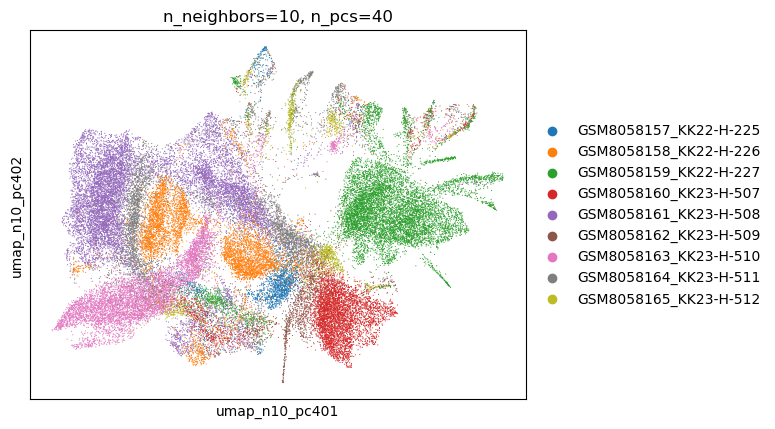

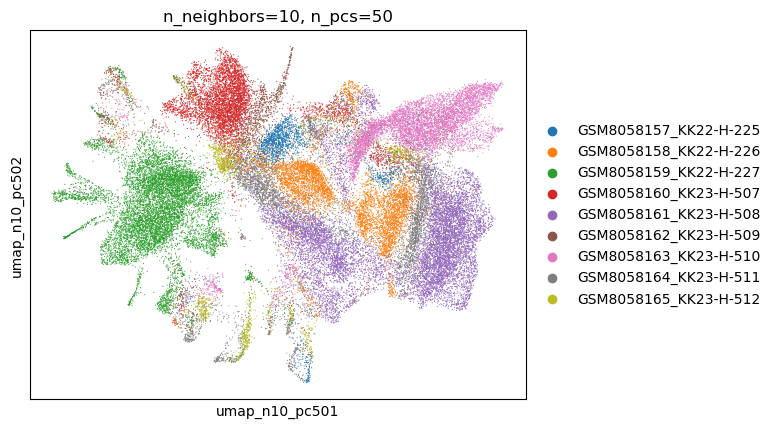

In [8]:
sc.pl.embedding(etmr1, basis="umap_n10_pc30", title="n_neighbors=10, n_pcs=30",color="orig.ident")
sc.pl.embedding(etmr1, basis="umap_n10_pc40", title="n_neighbors=10, n_pcs=40",color="orig.ident")
sc.pl.embedding(etmr1, basis="umap_n10_pc50", title="n_neighbors=10, n_pcs=50",color="orig.ident")

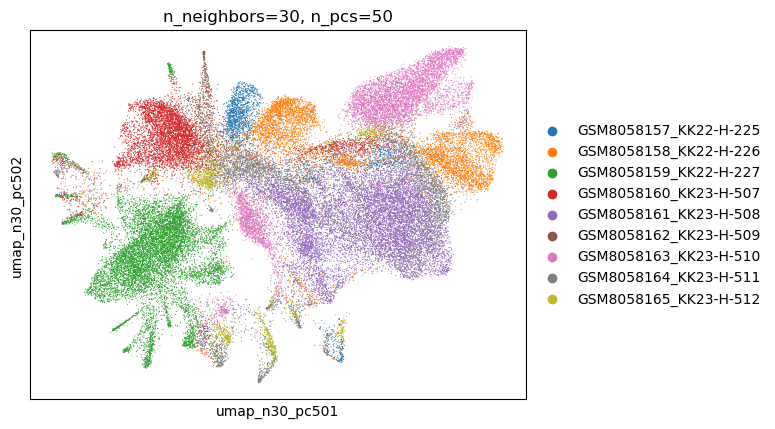

In [6]:
sc.pl.embedding(etmr1, basis="umap_n30_pc50", title="n_neighbors=30, n_pcs=50",color="orig.ident")

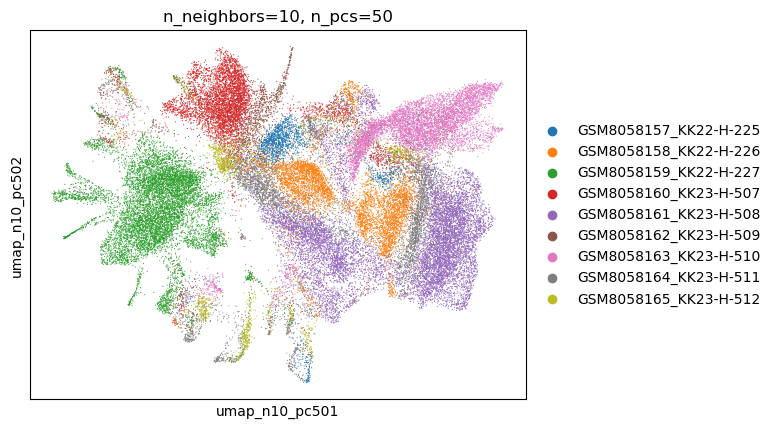

In [7]:
sc.pl.embedding(etmr1, basis="umap_n10_pc50", title="n_neighbors=10, n_pcs=50",color="orig.ident")

In [9]:
clustering_names =[l for l in etmr1.obs.columns if l.startswith("leiden")]
umap_names =[u for u in etmr1.obsm.keys() if u.startswith("umap")]

In [10]:
umap_names

['umap_n10_pc30',
 'umap_n10_pc40',
 'umap_n10_pc50',
 'umap_n15_pc30',
 'umap_n15_pc40',
 'umap_n15_pc50',
 'umap_n20_pc30',
 'umap_n20_pc40',
 'umap_n20_pc50',
 'umap_n25_pc30',
 'umap_n25_pc40',
 'umap_n25_pc50',
 'umap_n30_pc30',
 'umap_n30_pc40',
 'umap_n30_pc50',
 'umap_n35_pc30',
 'umap_n35_pc40',
 'umap_n35_pc50',
 'umap_n40_pc30',
 'umap_n40_pc40',
 'umap_n40_pc50']

In [11]:
clustering_names

['leiden_r0.5_n10_pc30',
 'leiden_r0.5_n10_pc40',
 'leiden_r0.5_n10_pc50',
 'leiden_r1.0_n10_pc30',
 'leiden_r1.0_n10_pc40',
 'leiden_r1.0_n10_pc50',
 'leiden_r1.5_n10_pc30',
 'leiden_r1.5_n10_pc40',
 'leiden_r1.5_n10_pc50',
 'leiden_r0.5_n15_pc30',
 'leiden_r0.5_n15_pc40',
 'leiden_r0.5_n15_pc50',
 'leiden_r1.0_n15_pc30',
 'leiden_r1.0_n15_pc40',
 'leiden_r1.0_n15_pc50',
 'leiden_r1.5_n15_pc30',
 'leiden_r1.5_n15_pc40',
 'leiden_r1.5_n15_pc50',
 'leiden_r0.5_n20_pc30',
 'leiden_r0.5_n20_pc40',
 'leiden_r0.5_n20_pc50',
 'leiden_r1.0_n20_pc30',
 'leiden_r1.0_n20_pc40',
 'leiden_r1.0_n20_pc50',
 'leiden_r1.5_n20_pc30',
 'leiden_r1.5_n20_pc40',
 'leiden_r1.5_n20_pc50',
 'leiden_r0.5_n25_pc30',
 'leiden_r0.5_n25_pc40',
 'leiden_r0.5_n25_pc50',
 'leiden_r1.0_n25_pc30',
 'leiden_r1.0_n25_pc40',
 'leiden_r1.0_n25_pc50',
 'leiden_r1.5_n25_pc30',
 'leiden_r1.5_n25_pc40',
 'leiden_r1.5_n25_pc50',
 'leiden_r0.5_n30_pc30',
 'leiden_r0.5_n30_pc40',
 'leiden_r0.5_n30_pc50',
 'leiden_r1.0_n30_pc30',


In [ ]:
for cluster_key in clustering_names:
    clusplot = sc.pl.embedding(etmr1, basis="umap_"+cluster_key[-8:], color=[cluster_key], legend_loc="on data", title=cluster_key+" umap", return_fig=True)
    clusplot.savefig(f"/home/sofia/Projects/etmr/defaria/snRNA/plots/clusters/umaps/umap_{cluster_key}.png")

In [ ]:
for cluster_key in clustering_names:
    for umap_name in umap_names:
        sc.pl.embedding(etmr1, basis=umap_name, color=[cluster_key], legend_loc="on data", title=cluster_key+"_"+umap_name)
        plt.savefig(f"/home/sofia/Projects/etmr/defaria/snRNA/plots/clusters/umaps/{umap_name}_{cluster_key}.png")#f-string
        plt.close()

In [54]:
etmr1

AnnData object with n_obs × n_vars = 49124 × 18082
    obs: 'orig.ident', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'Sample_ID', 'Tumor_Type', 'leiden_res0_25_n10_pc30', 'leiden_res0_5_n10_pc30', 'leiden_res1_n10_pc30', 'leiden_res1_5_n10_pc30', 'leiden_res0_25_n10_pc40', 'leiden_res0_5_n10_pc40', 'leiden_res1_n10_pc40', 'leiden_res1_5_n10_pc40', 'leiden_res0_25_n15_pc30', 'leiden_res0_5_n15_pc30', 'leiden_res1_n15_pc30', 'leiden_res1_5_n15_pc30', 'leiden_res0_25_n15_pc40', 'leiden_res0_5_n15_pc40', 'leiden_res1_n15_pc40', 'leiden_res1_5_n15_pc40', 'leiden_res0_25_n20_pc30', 'leiden_res0_5_n20_pc30', 'leiden_res1_n20_pc30', 'leiden_res1_5_n20_pc30', 'leiden_res0_25_n20_pc40', 'leiden_res0_5_n20_pc40', 'leiden_res1_n20_pc40', 'leiden_res1_5_n20_pc40', 'leiden_res0_25_n25_pc30', 'leiden_res0_5_n25_pc30', 'leiden_res1_n25_pc30', 'leiden_res1_5_n25_pc30', 'leiden_res0_25_n25_pc40', 'leiden_res0_5_n25_pc40', 'leiden_res1_n25_pc40', 'leiden_res1_5_n25_pc40', 'l

In [13]:
for cluster_key in clustering_names:
# Build proportion table (normalized by sample)
    cell_proportion_df = pd.crosstab(
    etmr1.obs[cluster_key],   # clusters on rows
    etmr1.obs['orig.ident'],                # samples on columns
    normalize='index'
)

# Plot stacked bar chart
    ax = cell_proportion_df.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

# Format the y-axis as percentages
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    plt.ylabel("Percentage")
    plt.xlabel("Cluster")
    plt.title(f"Sample Composition per Cluster {cluster_key}")
    plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"/home/sofia/Projects/etmr/defaria/snRNA/plots/clusters/sample_composition_per_cluster_{cluster_key}.png")#f-string
    plt.close()